# Surrogate / oracle on the 70%-identity split — and comparison to the random split

Trains the **same** two fixed models as `surrogate_oracle_peak_dual.ipynb` —
surrogate = `cnn-max-d1`, oracle = `cnn-concatstd-d1` — with the **same architectures, loss,
hyperparameters, and ESM-2 embedding cache**, but on the homology-aware
`dual_splits_seqid70.csv` produced by `seqid70_cluster_split.ipynb`. It then compares peak-MAE
against the existing random-split models.

**Nothing existing is modified.** We import `peak_models.py` read-only, reuse the shared
`esm_residue_fp16.npy` cache, and write new checkpoints under a `seqid70_` prefix (the existing
`dual_*` weights and `surrogate_oracle_peak_dual.ipynb` are left untouched).

> Prerequisite: run `seqid70_cluster_split.ipynb` first (it writes `dual_splits_seqid70.csv`).


## 0. Setup + data + per-residue embeddings  *(identical to the dual notebook)*

In [ ]:
import os, sys
# Moved into peak_design/cluster_split/. These notebooks are written to run from
# peak_design/, so re-anchor cwd + import path there; every relative path
# (../dataset_pipeline, trained_models/, oracle_cv_cache/) then resolves unchanged.
if os.path.basename(os.getcwd()) == "cluster_split":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [1]:
import csv, os, numpy as np, torch, torch.nn as nn, hashlib, time
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8","dragon":"#c85152"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32)       # (N,2) [ex_max, em_max] nm
EXM=peaks[:,0]; EMM=peaks[:,1]
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
assert all(s is not None for s in seqs), "missing sequences"

# same row-aligned ESM-2 per-residue cache the dual notebook uses (built by dataset_pipeline/embed.py)
RP=os.path.join(CUR,"esm_residue_fp16.npy"); LP=os.path.join(CUR,"esm_residue_len.npy")
assert os.path.exists(RP), "embedding cache missing -- run: python ../dataset_pipeline/embed.py --trait peak"
H=np.load(RP); Ls=np.load(LP); Lmax=int(Ls.max()); H=H[:,:Lmax]
Ht=torch.tensor(H); ar=torch.arange(Lmax); os.makedirs("trained_models",exist_ok=True)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N)


device mps | N 758


## 1. Load the 70%-identity coordinated dual split

In [2]:
SPLIT=os.path.join(CUR,"dual_splits_seqid70.csv")
assert os.path.exists(SPLIT), "run seqid70_cluster_split.ipynb first (writes dual_splits_seqid70.csv)"
ds=sorted(csv.DictReader(open(SPLIT)), key=lambda r:int(r["index"]))
assert len(ds)==N
Srole=np.array([r["surrogate_role"] for r in ds]); Orole=np.array([r["oracle_role"] for r in ds])
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
assert np.sum((Srole=="val")&(Orole=="val"))==0
def cnt(a): return {b:int((a==b).sum()) for b in ("train","val","test")}
print("seqid70 split | surrogate (S):",cnt(Srole),"| oracle (O):",cnt(Orole))
SIDX={b:np.where(Srole==b)[0] for b in ("train","val","test")}
OIDX={b:np.where(Orole==b)[0] for b in ("train","val","test")}


seqid70 split | surrogate (S): {'train': 512, 'val': 117, 'test': 129} | oracle (O): {'train': 530, 'val': 114, 'test': 114}


## 2. Models + training helpers  *(same code path as the dual notebook)*

In [3]:
DROP=0.2; LR=1e-3; WD=1e-4; EP_CNN=150; FORCE=False
SEED=0                      # fix init/shuffle so this homology-aware run is reproducible
MODELS=[dict(arch="cnn", pool="max",       conv_ch=128, k=5, n_conv=1, hidden=256, nl=2, sid="cnn-max-d1"),
        dict(arch="cnn", pool="concatstd", conv_ch=128, k=5, n_conv=1, hidden=256, nl=2, sid="cnn-concatstd-d1")]
SPEC={m["sid"]:m for m in MODELS}
SURR_SID, ORAC_SID = "cnn-max-d1", "cnn-concatstd-d1"

def standardizer(idx):
    m=peaks[idx].mean(0); s=peaks[idx].std(0)+1e-6; return m.astype(np.float32), s.astype(np.float32)
def wrapw(base, mean, std): return pm.wrap(base, mean, std, dev)
def load_wrapped(path, mean, std): base,ck=pm.load_model(path,dev); return wrapw(base,mean,std), ck

Pk=torch.tensor(peaks, dtype=torch.float32, device=dev)
def predict_peaks(net, idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
def _r2(t,p):
    t=np.asarray(t,float); p=np.asarray(p,float); ss=((t-t.mean())**2).sum()
    return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
def evaluate(net, idx):
    P=predict_peaks(net, idx); T=peaks[idx]
    ex=float(np.abs(P[:,0]-T[:,0]).mean()); em=float(np.abs(P[:,1]-T[:,1]).mean())
    return dict(mae=0.5*(ex+em), ex_mae=ex, em_mae=em, r2_ex=_r2(T[:,0],P[:,0]), r2_em=_r2(T[:,1],P[:,1]))
def fit(net, mean, std, tr, va, epochs):                  # standardized-peak MSE; early-stop on val MAE (nm)
    sd=torch.tensor(std,device=dev); opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD)
    best=1e9; bst=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad()
            pred=net(Hb,mk); tgt=Pk[torch.as_tensor(b,device=dev)]
            loss=(((pred-tgt)/sd)**2).mean(); loss.backward(); opt.step()
        v=evaluate(net,va)["mae"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.base.state_dict().items()}
    net.base.load_state_dict(bst); return net

DATASIG=hashlib.md5(Srole.tobytes()+Orole.tobytes()).hexdigest()[:8]   # differs from the random split's sig
print("seqid70 DATASIG",DATASIG)
def get_or_train(spec, dsname, tr, va, te, mean, std):
    path=os.path.join("trained_models", f"seqid70_{dsname}_{spec['sid']}_peaks_{DATASIG}.pt")
    if os.path.exists(path) and not FORCE:
        net,_=load_wrapped(path, mean, std)
        return {"train":evaluate(net,tr),"val":evaluate(net,va),"test":evaluate(net,te)}, True, path
    torch.manual_seed(SEED); np.random.seed(SEED)
    base=pm.build_base(spec, dev, drop=DROP); net=wrapw(base, mean, std)
    fit(net, mean, std, tr, va, EP_CNN)
    met={"train":evaluate(net,tr),"val":evaluate(net,va),"test":evaluate(net,te)}
    meta=dict(spec); meta.update(out=pm.N_PEAKS, drop=DROP, sid=spec["sid"], metrics=met, loss="std-mse",
                                 split="seqid70", peak_mean=mean.tolist(), peak_std=std.tolist())
    pm.save_model(path, net.base, meta); return met, False, path
print("models:", [m["sid"] for m in MODELS])


seqid70 DATASIG e03357eb
models: ['cnn-max-d1', 'cnn-concatstd-d1']


## 3. Train surrogate (`cnn-max-d1` on S) and oracle (`cnn-concatstd-d1` on O)

In [4]:
def run(dsname, IDX, sid):
    mean,std=standardizer(IDX["train"])
    met,cached,path=get_or_train(SPEC[sid], dsname, IDX["train"], IDX["val"], IDX["test"], mean, std)
    print(f"{dsname:5s} {sid:16s} {'(cached)' if cached else '(trained)'} | "
          f"train MAE {met['train']['mae']:4.1f} | val MAE {met['val']['mae']:4.1f} "
          f"(ex {met['val']['ex_mae']:4.1f} em {met['val']['em_mae']:4.1f}) R2 ex {met['val']['r2_ex']:.2f} em {met['val']['r2_em']:.2f} "
          f"| test MAE {met['test']['mae']:4.1f}")
    return met,path,(mean,std)
t0=time.time()
surr_met, surr_path, surr_scaler = run("surr", SIDX, SURR_SID)
orac_met, orac_path, orac_scaler = run("orac", OIDX, ORAC_SID)
print(f"done in {time.time()-t0:.0f}s")


surr  cnn-max-d1       (trained) | train MAE  4.5 | val MAE 28.1 (ex 38.1 em 18.0) R2 ex 0.22 em 0.68 | test MAE 18.1


orac  cnn-concatstd-d1 (trained) | train MAE  3.7 | val MAE 37.3 (ex 40.3 em 34.4) R2 ex -0.05 em 0.11 | test MAE 36.0
done in 214s


## 4. Save chosen seqid70 models  *(new files — existing `dual_*` weights untouched)*

In [5]:
import shutil
shutil.copy(surr_path, os.path.join("trained_models","seqid70_surrogate_net.pt"))
shutil.copy(orac_path, os.path.join("trained_models","seqid70_oracle_net.pt"))
np.savez(os.path.join("trained_models","seqid70_surrogate_scaler.npz"), mean=surr_scaler[0], std=surr_scaler[1])
np.savez(os.path.join("trained_models","seqid70_oracle_scaler.npz"),    mean=orac_scaler[0], std=orac_scaler[1])
print("saved -> trained_models/seqid70_surrogate_net.pt, seqid70_oracle_net.pt (+ scalers)")


saved -> trained_models/seqid70_surrogate_net.pt, seqid70_oracle_net.pt (+ scalers)


## 5. Parity — oracle predicted vs. true peak, by split region

oracle = cnn-concatstd-d1
region                        n    MAE  ex_MAE  em_MAE  R2_ex  R2_em


O_train                     530    3.7     4.1     3.3   0.99   0.99
O_val                       114   37.3    40.3    34.4  -0.05   0.11


O_test (unseen lineages)    114   36.0    34.9    37.1   0.36   0.37


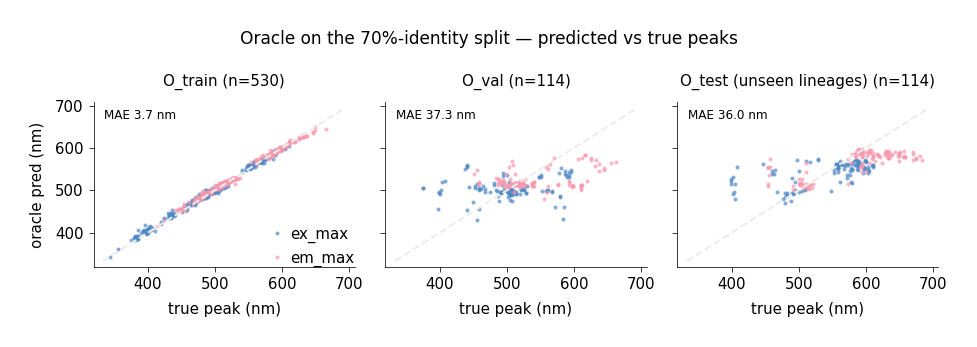

In [6]:
orac_net,_=load_wrapped(orac_path,*orac_scaler)
groups=[("O_train",OIDX["train"]),("O_val",OIDX["val"]),("O_test (unseen lineages)",OIDX["test"])]
print(f"oracle = {ORAC_SID}")
print(f"{'region':26s} {'n':>4} {'MAE':>6} {'ex_MAE':>7} {'em_MAE':>7} {'R2_ex':>6} {'R2_em':>6}")
for name,idx in groups:
    m=evaluate(orac_net,idx)
    print(f"{name:26s} {len(idx):>4} {m['mae']:6.1f} {m['ex_mae']:7.1f} {m['em_mae']:7.1f} {m['r2_ex']:6.2f} {m['r2_em']:6.2f}")
if HAVE_PLT:
    lo=float(min(EXM.min(),EMM.min()))-10; hi=float(max(EXM.max(),EMM.max()))+10
    fig,axes=plt.subplots(1,3,figsize=(13.2,4.3),sharex=True,sharey=True)
    for c,(name,idx) in enumerate(groups):
        P=predict_peaks(orac_net,idx); a=axes[c]; a.plot([lo,hi],[lo,hi],ls="--",color=apc_c.gray)
        a.scatter(peaks[idx,0],P[:,0],s=16,color=apc_c.aegean,alpha=0.7,label="ex_max")
        a.scatter(peaks[idx,1],P[:,1],s=16,color=apc_c.rose,alpha=0.7,label="em_max")
        m=evaluate(orac_net,idx)
        a.text(0.04,0.96,f"MAE {m['mae']:.1f} nm",transform=a.transAxes,va="top",fontsize=12,
               bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="none"))
        a.set_title(f"{name} (n={len(idx)})"); a.set_xlabel("true peak (nm)")
    axes[0].set_ylabel("oracle pred (nm)"); axes[0].legend()
    plt.suptitle("Oracle on the 70%-identity split — predicted vs true peaks"); plt.tight_layout(); plt.show()


## 6. Robust reporting — median peak MAE + bootstrap 95% CI  *(same estimator as the dual notebook)*

In [7]:
def _abs_err(net, idx):
    P=predict_peaks(net,idx); T=peaks[idx]; return 0.5*(np.abs(P[:,0]-T[:,0])+np.abs(P[:,1]-T[:,1])), P, T
def boot_med(e,B=3000,seed=0):
    r=np.random.default_rng(seed); bs=np.median(e[r.integers(0,len(e),(B,len(e)))],axis=1)
    return float(np.median(e)),float(np.percentile(bs,2.5)),float(np.percentile(bs,97.5))
surr_net,_=load_wrapped(surr_path,*surr_scaler)
print(f"{'model / split':26s} {'n':>4} | {'median MAE [95% CI] nm':>26} | {'mean':>5}")
for tag,net,IDX in [("surrogate cnn-max",surr_net,SIDX),("oracle cnn-concatstd",orac_net,OIDX)]:
    for s in ("train","val","test"):
        e,_,_=_abs_err(net,IDX[s]); med,lo,hi=boot_med(e)
        print(f"{tag+' / '+s:26s} {len(e):>4} | {med:6.1f} [{lo:5.1f}, {hi:5.1f}]{'':7s} | {e.mean():5.1f}")


model / split                 n |     median MAE [95% CI] nm |  mean


surrogate cnn-max / train   512 |    3.1 [  2.8,   3.4]        |   4.5
surrogate cnn-max / val     117 |   23.1 [ 19.6,  27.0]        |  28.1


surrogate cnn-max / test    129 |   14.9 [ 12.8,  16.6]        |  18.1


oracle cnn-concatstd / train  530 |    3.3 [  2.8,   3.5]        |   3.7
oracle cnn-concatstd / val  114 |   29.8 [ 20.8,  37.8]        |  37.3


oracle cnn-concatstd / test  114 |   31.8 [ 24.9,  39.3]        |  36.0


## 7. Head-to-head: random split vs. 70%-identity split

We load the **existing random-split checkpoints** (`trained_models/dual_surrogate_net.pt`,
`dual_oracle_net.pt`) and evaluate them on the **random** test set, and put the numbers next to the
freshly trained **seqid70** models on the **seqid70** test set. Same architectures, same loss, same
embeddings, same fixed model roles — only the split differs.

Each model is evaluated on its *own* held-out test set (evaluating a random-trained model on
seqid70-test would itself be leaky, since it trained on those lineages). The random test set is
~95% homolog-leaked, so its MAE is the optimistic number; the seqid70 test set is leak-free, so its
MAE reflects generalization to **unseen sequence families** — the regime that matters when the
design loop proposes novel sequences.

In [8]:
# random split + its saved models/scalers
rnd=sorted(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))), key=lambda r:int(r["index"]))
RSrole=np.array([r["surrogate_role"] for r in rnd]); ROrole=np.array([r["oracle_role"] for r in rnd])
RSIDX={b:np.where(RSrole==b)[0] for b in ("train","val","test")}
ROIDX={b:np.where(ROrole==b)[0] for b in ("train","val","test")}
def load_saved(net_pt, scaler_npz):
    sc=np.load(os.path.join("trained_models",scaler_npz)); base,_=pm.load_model(os.path.join("trained_models",net_pt),dev)
    return pm.wrap(base,sc["mean"],sc["std"],dev)
r_surr=load_saved("dual_surrogate_net.pt","dual_surrogate_scaler.npz")
r_orac=load_saved("dual_oracle_net.pt","dual_oracle_scaler.npz")

def row(net,idx):
    m=evaluate(net,idx); return m["mae"],m["ex_mae"],m["em_mae"],m["r2_ex"],m["r2_em"]
comp=[]
comp.append(("surrogate","random  (leaky test)", *row(r_surr,RSIDX["test"]), len(RSIDX["test"])))
comp.append(("surrogate","seqid70 (unseen fam)", *row(surr_net,SIDX["test"]), len(SIDX["test"])))
comp.append(("oracle",   "random  (leaky test)", *row(r_orac,ROIDX["test"]), len(ROIDX["test"])))
comp.append(("oracle",   "seqid70 (unseen fam)", *row(orac_net,OIDX["test"]), len(OIDX["test"])))
print(f"{'model':10s} {'split (test set)':22s} {'n':>4} {'MAE':>6} {'ex_MAE':>7} {'em_MAE':>7} {'R2_ex':>6} {'R2_em':>6}")
for r in comp:
    print(f"{r[0]:10s} {r[1]:22s} {r[7]:>4} {r[2]:6.1f} {r[3]:7.1f} {r[4]:7.1f} {r[5]:6.2f} {r[6]:6.2f}")

d_surr=comp[1][2]-comp[0][2]; d_orac=comp[3][2]-comp[2][2]
print(f"\nHomology-honest test MAE is higher by {d_surr:+.1f} nm (surrogate) and {d_orac:+.1f} nm (oracle):")
print("the random split's lower MAE is inflated by ~95% train/test homolog leakage.")


model      split (test set)          n    MAE  ex_MAE  em_MAE  R2_ex  R2_em
surrogate  random  (leaky test)    114   11.2    13.4     9.0   0.77   0.87
surrogate  seqid70 (unseen fam)    129   18.1    19.2    17.0  -0.06  -0.25
oracle     random  (leaky test)    114   13.4    17.0     9.8   0.69   0.84
oracle     seqid70 (unseen fam)    114   36.0    34.9    37.1   0.36   0.37

Homology-honest test MAE is higher by +6.9 nm (surrogate) and +22.6 nm (oracle):
the random split's lower MAE is inflated by ~95% train/test homolog leakage.


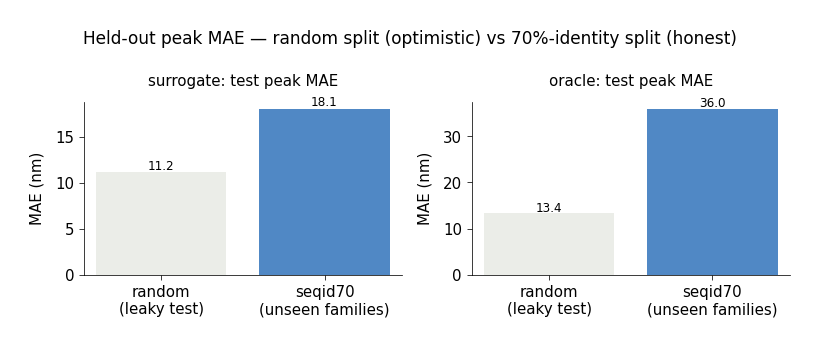

In [9]:
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(11,4.3))
    for c,(mdl,rows_) in enumerate([("surrogate",comp[:2]),("oracle",comp[2:])]):
        a=ax[c]; labs=["random\n(leaky test)","seqid70\n(unseen families)"]
        mae=[rows_[0][2],rows_[1][2]]; b=a.bar(labs,mae,color=[apc_c.gray,apc_c.aegean])
        for rr,v in zip(b,mae): a.text(rr.get_x()+rr.get_width()/2,v+0.3,f"{v:.1f}",ha="center",fontsize=12)
        a.set_title(f"{mdl}: test peak MAE"); a.set_ylabel("MAE (nm)")
    plt.suptitle("Held-out peak MAE — random split (optimistic) vs 70%-identity split (honest)")
    plt.tight_layout(); plt.show()


## 8. Interpretation

- The surrogate/oracle **architectures, loss, hyperparameters, and ESM-2 embeddings are unchanged**;
  only the split differs (`dual_splits_seqid70.csv` vs `dual_splits.csv`). New checkpoints are saved
  under `seqid70_*` — the original `dual_*` weights and notebook are untouched.
- On the **random** split ~95% of test proteins have a ≥70%-identity homolog in training, so its
  test MAE is an **optimistic** estimate — the model is largely interpolating within lineages it has
  already seen.
- On the **70%-identity** split the test proteins belong to lineages **absent from training**, so its
  (higher) MAE is the honest estimate of how the surrogate/oracle generalize to the novel sequences
  the design loop actually proposes.
- The gap between the two is the amount of apparent accuracy that was coming from homology leakage.
  For judging design success, the oracle's seqid70 number is the more trustworthy yardstick.
